# Homework #2
## Introduction to unsupervised learning


This colaboratory contains Homework #2 which is due **February 23 midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**
## Submission's rules:
*(just in case reminding you)*
1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

##List of Homework's exercises:

1.   [Ex1](#scrollTo=1YXt-Gxw9UY7) - 4 points
2.   [Ex2](#scrollTo=x93C489B3rq9) - 3 points
3.   [Ex3](#scrollTo=6ixMMWLE1XGr) - 3 points
4.   [Bonus 1](#scrollTo=93rYhdhm3by8) - 0.5 points
5.   [Bonus 2](#scrollTo=IhIMUQjs3bzV) -  0.5 points
6.   [Bonus 3](#scrollTo=3vwwyCwumcxJ&line=3&uniqifier=1) - 4 points



## HW Setup:

In [1]:
# The three giants on top which everything else is built
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We don't like warnings
import warnings
warnings.filterwarnings('ignore')

# For plotting like a pro
!pip install -q plotnine
from plotnine import *

from tensorflow.keras.datasets import mnist

## Homework exercise 1 (4 points): PCA on MNIST
<font color='red'> In this exercise we shall look into the effects of using PCA on the execution time of ML algorithms as well as their performance. To this end we will load **the entire** MNIST dataset.
</font>

In [2]:
(train_images, train_labels),(test_images, test_labels) = mnist.load_data()
train_images = train_images / 255 # normalising train images
test_images = test_images / 255 # normalising test images

# reshaping each image 28x28 into a vector of 784 values
# needed for the scikit learn to work properly
train_images = train_images.reshape(train_images.shape[0], train_images.shape[1]*train_images.shape[2])
test_images = test_images.reshape(test_images.shape[0], test_images.shape[1]*test_images.shape[2])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


<font color='red'> Here we perform standardization of both training and test sets using mean and standard deviation computed based on training data (because in reality test set statistics is not available).
</font>

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Here we evaluate mean and standard deviation based on training.
scaler.fit(train_images)

# Apply transform to both the training set and the test set.
train_images = scaler.transform(train_images)
test_images = scaler.transform(test_images)

<font color='red'> In this exercise we will use another type of linear model called Logistic Regression. We have not discussed this model in the lecture, hence we give it a short introduction here. Logistic Regression is very similar to Linear Regression model that we had an opportunity to try last time, with an important difference - it is a **classification model**. Also, unlike Linear Regression which uses the least squares method to fit the line, Logistic Regression uses a principle called **maximum likelihood** to fit the model. In simpler terms, you can think of Logistic Regression is an extension to Linear Regression that helps to convert continuous predictions into probabilities and then to classes.

For the sake of this exercise, you do not need to know all the details of the method. [Here](https://towardsdatascience.com/logistic-regression-explained-9ee73cede081) you can find more information about Logistic Regression and maximum likelihood method.
</font>

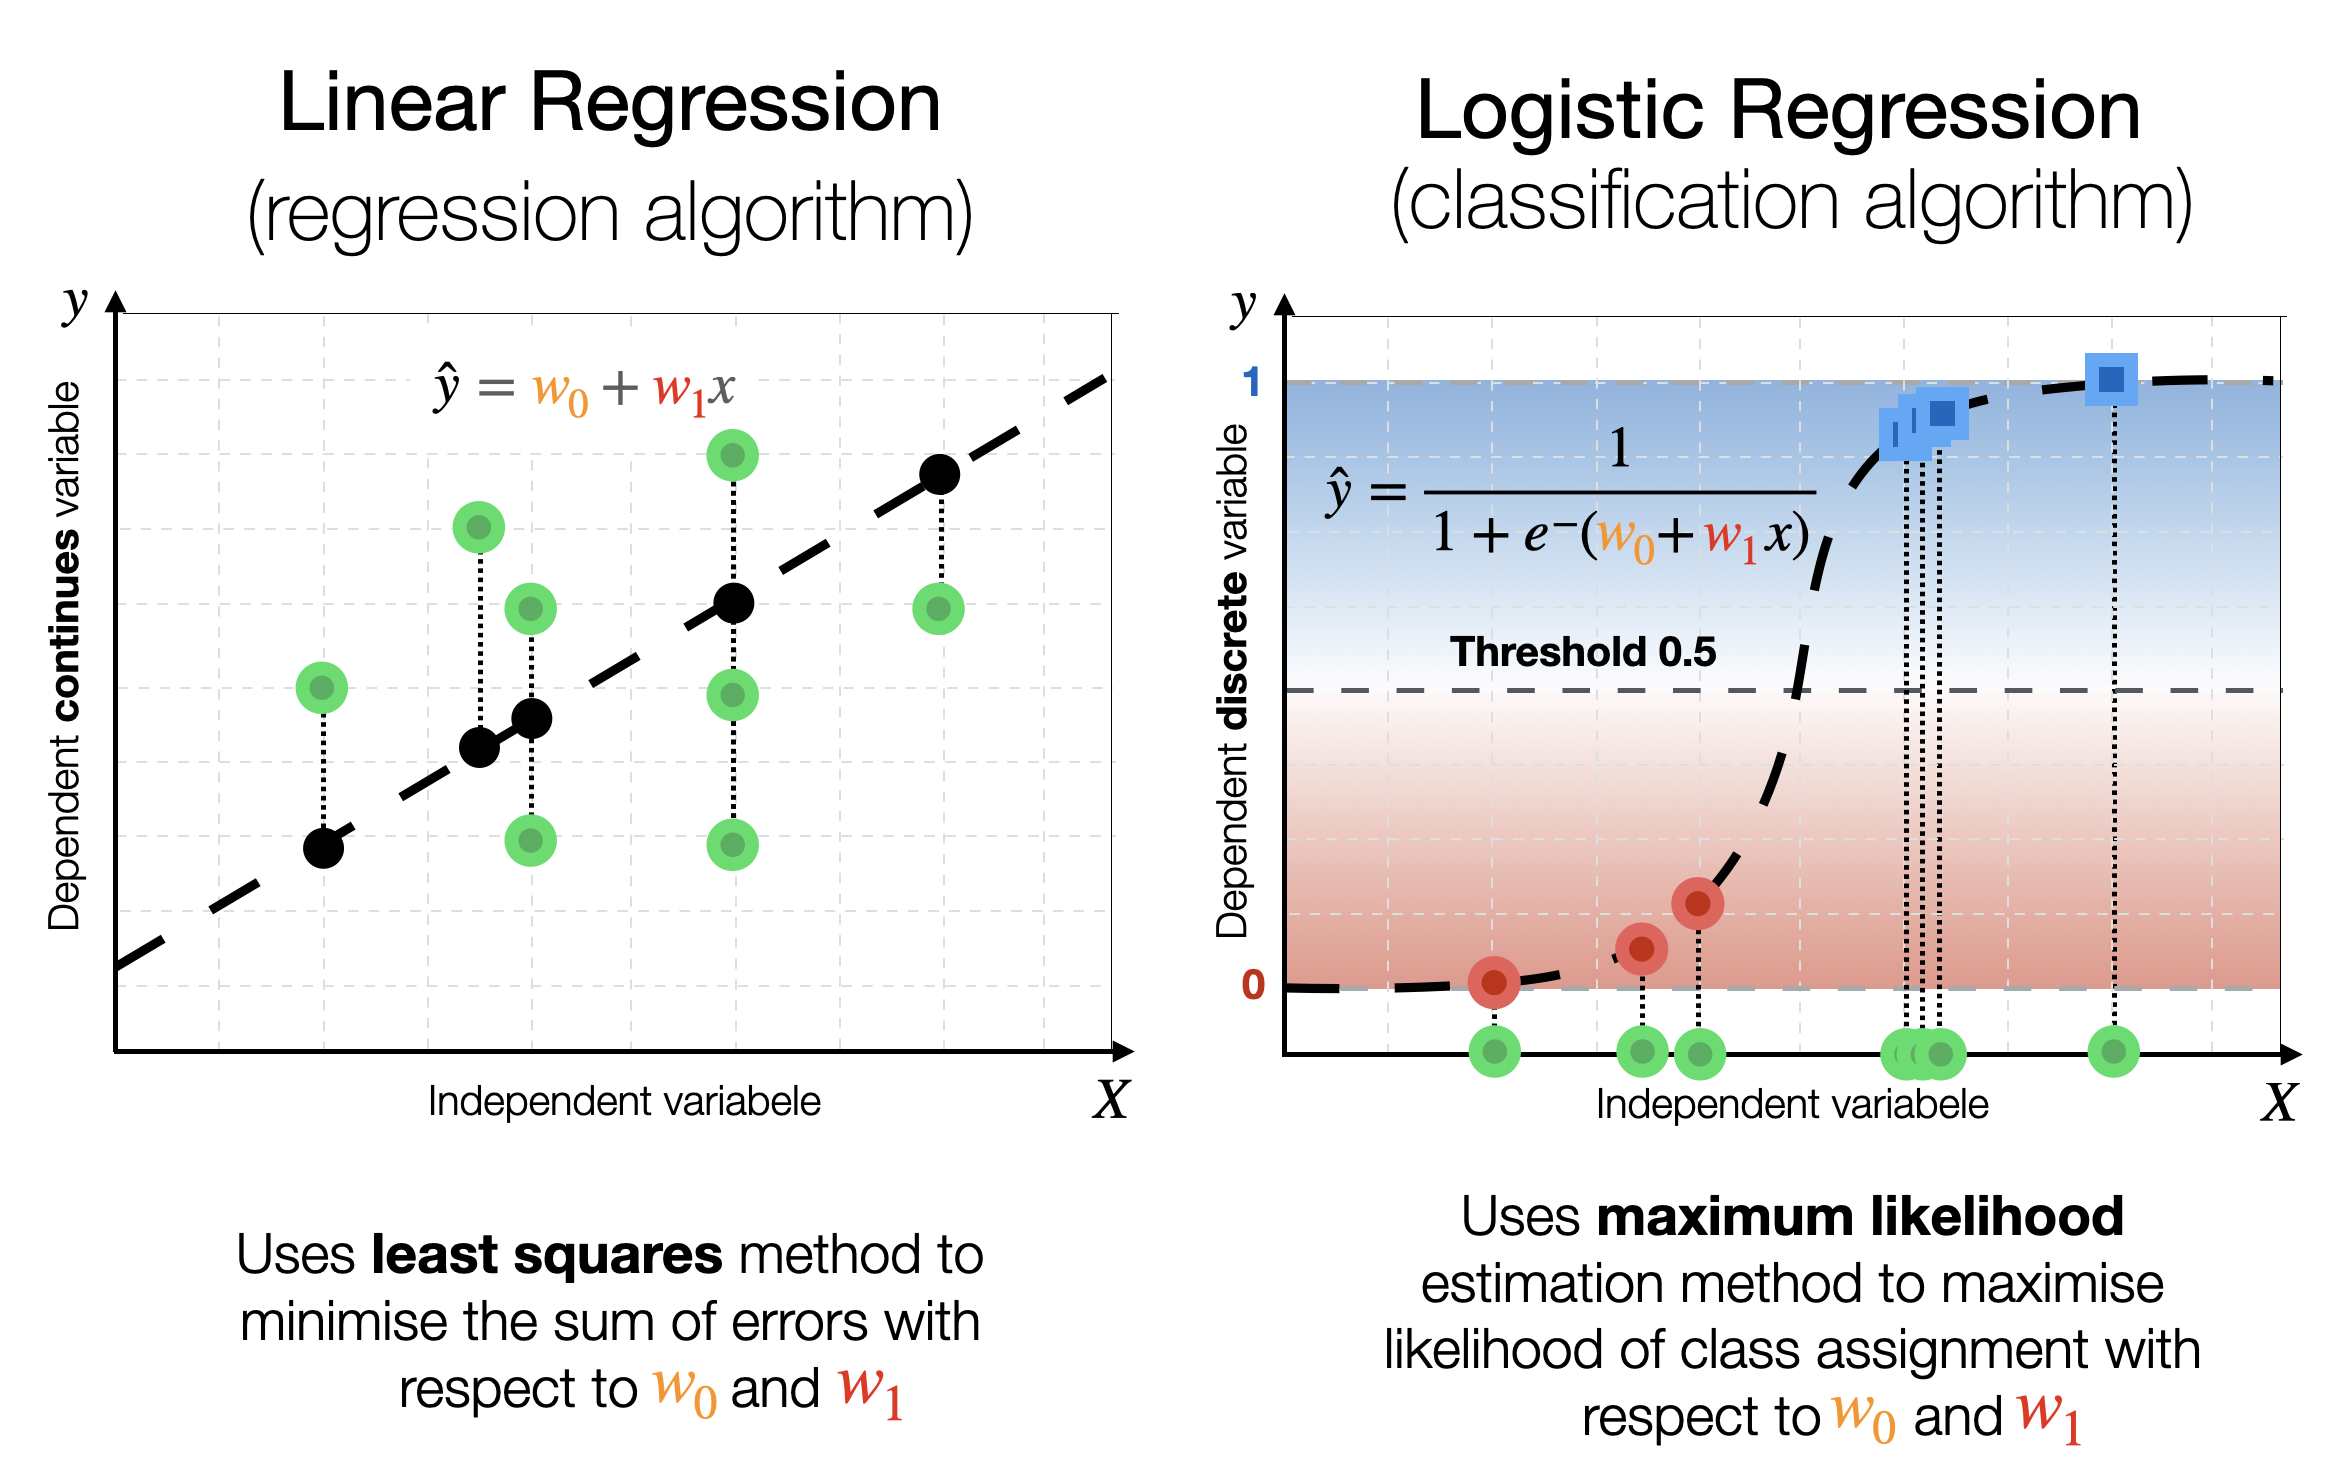

<font color='red'>**(Homework exercise 1- a)** Run vanila Logistic Regression on original data, calculate and report the score (which in this case is accuracy) and fitting time (use `time` library as in the practice session). (1 point)
</font>

In [ ]:
from sklearn.linear_model import LogisticRegression
import time

# default solver is incredibly slow hence you should use 'lbfgs'
logisticRegr = LogisticRegression(solver = 'lbfgs')

##### YOUR CODE STARTS #####
start_time = time.time()
logisticRegr.fit(train_images, train_labels)
exec_time = time.time() - start_time
score = logisticRegr.score(test_images, test_labels)
##### YOUR CODE ENDS #####

n_features = train_images.shape[1]
print(f"It took {exec_time} seconds to get {score} accuracy using {n_features} features")

It took 68.53834056854248 seconds to get 0.9246 accuracy using 784 features


<font color='red'>**(Homework exercise 1- b)** Perform a PCA on MNIST data. Retain as many PCs as needed to explain 90% of original variance. Visualise the projections on the first two principle components of the training images usign the scatter plot. (1 point)

In [ ]:
from sklearn.decomposition import PCA
##### YOUR CODE STARTS #####
# Fit PCA on train images
pca_09 = PCA(n_components=0.90)
pca_09.fit(train_images)
train_images_compressed = pca_09.transform(train_images)
test_images_compressed = pca_09.transform(test_images)
##### YOUR CODE ENDS #####

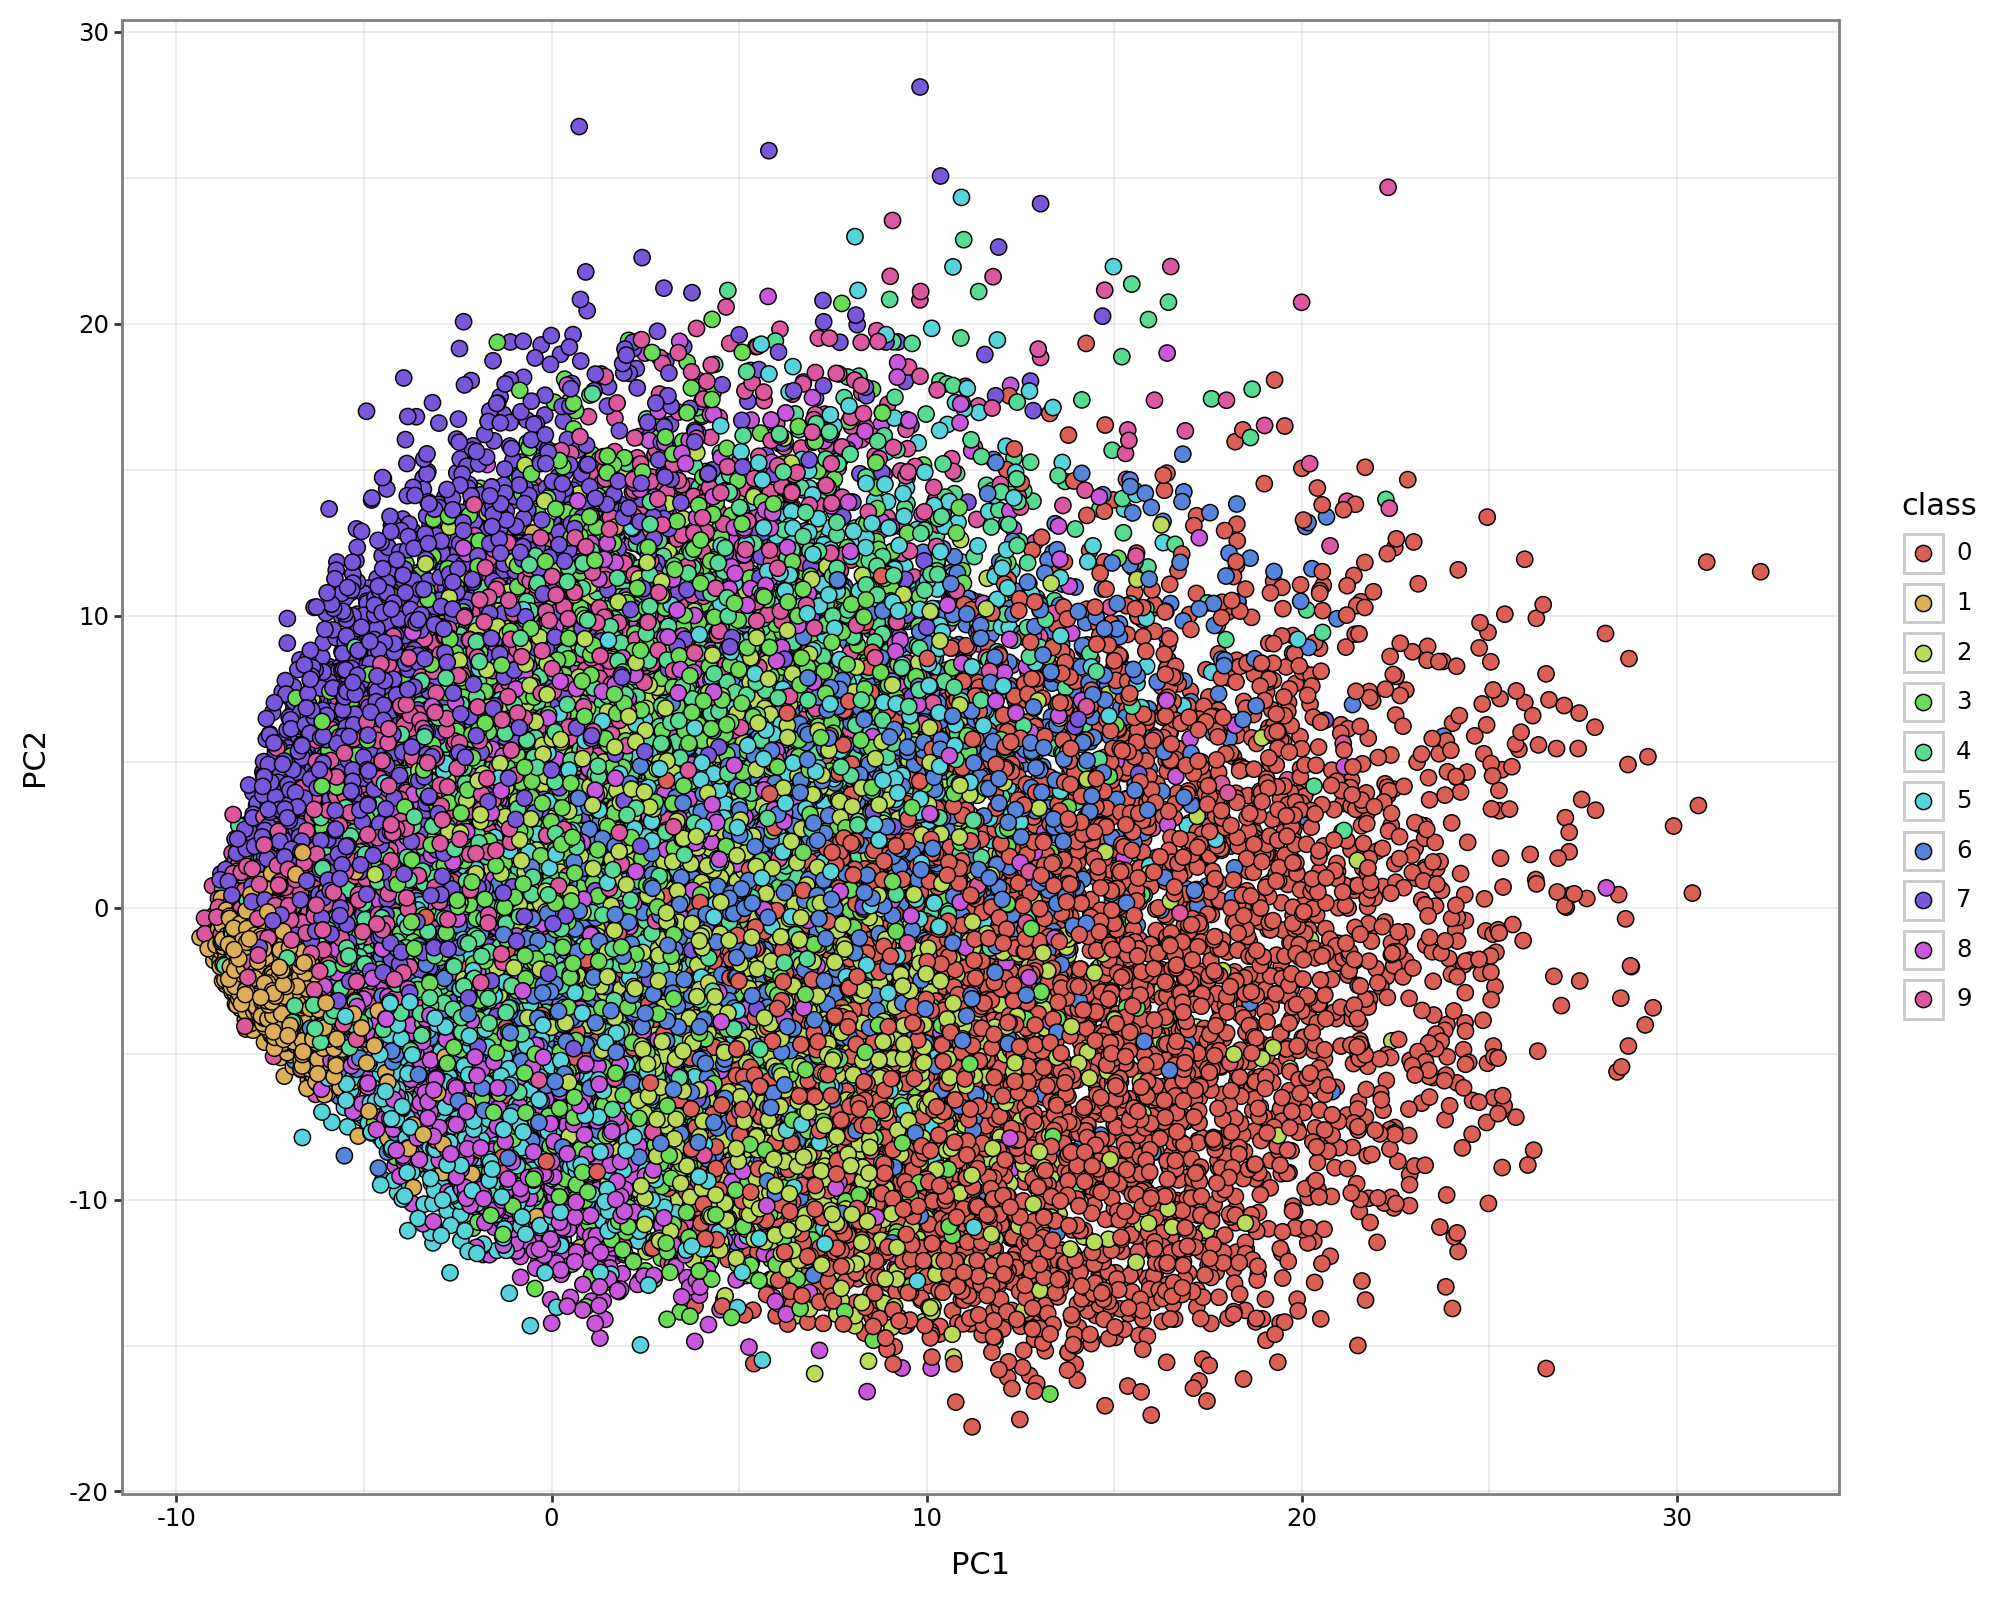

In [ ]:
##### YOUR CODE STARTS #####
visualise_train = pd.DataFrame(train_images_compressed[:, :2], columns=['PC1', 'PC2'])
visualise_train['class'] = train_labels
##### YOUR CODE ENDS #####

visualise_train['class'] = visualise_train['class'].astype("category")
fig = (
    ggplot(data = visualise_train,
          mapping = aes(x = 'PC1', y = 'PC2')) +
    geom_point(aes(fill = 'class'), size = 3, shape = 'o', stroke = 0.3) +

    # All the style related codes goes here:
    labs(title ='', x = 'PC1', y = 'PC2',) +
    theme_bw() +
    theme(figure_size = (10, 8),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black'))
).show()

<font color='red'>**(Homework exercise 1- c)** Fit the  Logistic Regression on `train_images_compressed`, calculate and report the fitting time, the accuracy on test images (aka `score`) and the number of principle components that were kept (in `n_features`). (0.5 points)
</font>

In [ ]:
logisticRegr = LogisticRegression(solver = 'lbfgs')
##### YOUR CODE STARTS #####
start_time = time.time()
logisticRegr.fit(train_images_compressed, train_labels)
exec_time = time.time() - start_time
score = logisticRegr.score(test_images_compressed, test_labels)
n_features = train_images_compressed.shape[1]
##### YOUR CODE ENDS #####
print(f"It took {exec_time} seconds to get {score} accuracy using {n_features} features")

It took 9.151573657989502 seconds to get 0.9281 accuracy using 236 features


<font color='red'>**(Homework exercise 1- d)** Combine **1-b** (except for visualisation of PCA) and **1-c** in the for loop, every time retaining different amount of variance (from 0.85 to 0.5 with a step of 0.05). In every iteration collect information on how much the execution time and accuracy changes with respect to the number of principle components kept by the PCA. (1 point).
</font>

In [ ]:
for variance in [0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5]:
  print(f"Retaining {variance*100}% of variance")
  ##### YOUR CODE STARTS #####
  pca = PCA(n_components=variance)
  pca.fit(train_images)
  train_images_compressed = pca.transform(train_images)
  test_images_compressed = pca.transform(test_images)

  logisticRegr = LogisticRegression(solver='lbfgs')
  start_time = time.time()
  logisticRegr.fit(train_images_compressed, train_labels)
  exec_time = time.time() - start_time
  score = logisticRegr.score(test_images_compressed, test_labels)
  n_features = train_images_compressed.shape[1]
  ##### YOUR CODE ENDS #####
  print(f"It took {exec_time} seconds to get {score} using {n_features} features")

Retaining 85.0% of variance
It took 7.159073352813721 seconds to get 0.9264 using 185 features
Retaining 80.0% of variance
It took 7.357111692428589 seconds to get 0.9237 using 149 features
Retaining 75.0% of variance
It took 7.158203363418579 seconds to get 0.9214 using 120 features
Retaining 70.0% of variance
It took 5.04269552230835 seconds to get 0.9196 using 98 features
Retaining 65.0% of variance
It took 5.319194793701172 seconds to get 0.9174 using 80 features
Retaining 60.0% of variance
It took 4.14747428894043 seconds to get 0.9108 using 64 features
Retaining 55.00000000000001% of variance
It took 3.9704153537750244 seconds to get 0.9042 using 50 features
Retaining 50.0% of variance
It took 4.509552240371704 seconds to get 0.9001 using 39 features


<font color='red'>**(Homework exercise 1- e)** Shortly answer the following questions (0.5 points):  
* What is the minimum number of principle components was needed in **1- d** to approximately match the performance on the original data?
* How much faster was the model trained on smaller data?
* What are the main advantages and disadvantages of PCA transformation?
* When would you use the PCA transformation and when you wouldn't?
</font>

Answer (e):

1. The original accuracy was 0.9246 with 784 features. The exactly same accuracy was 0.9264 with 185 features at 85% variance, thus 185 principal components were needed to approximately match the original model's performance.

2. The original model took 68.54 seconds with 784 features. The fastest PCA-transformed model took 3.97 seconds with 50 features. The PCA model with 185 features (which had comparable accuracy) took 7.16 seconds. So, the PCA-transformed model with 185 features was about 9.6 times faster than the original model (68.54 / 7.16 ≈ 9.6x speedup).

3. Advantages:  
   - Reduces dimensionality, improving computational efficiency and speed  
   - Helps in avoiding overfitting by removing redundant features  
   - Improves visualization by reducing data to 2D or 3D components.
   - Removes noise by filtering out less informative components

   Disadvantages:
   - PCA is a linear transformation and may not capture complex non-linear structures in data.  
   - Reduces interpretability because transformed features no longer correspond to original features.  
   - Some important feature information might be lost during transformation.  

4. Use PCA when:  
   - The dataset has a large number of features, and training is computationally expensive
   - There is high correlation (multicollinearity) between features
   - We need to reduce dimensionality for visualization or want to denoise the data by filtering out low-variance components

   Avoid PCA when:
   - Feature interpretability is important (medical diagnosis where feature meanings matter)
   - The dataset has complex, non-linear relationships.  
   - We are working with categorical data, as PCA is mainly for continuous numerical data.  

## Homework exercise 2 (3 points): Increasing the dimensionality

<font color='red'> In the lecture and also in the practice session we have mostly discussed benefits of reducing the number of dimensions. It turns out (as often in life) that the opposite i.e. adding features can also sometimes be very useful. For example, we have seen in the first homework, how constructing a better distance measure helps us predict taxi ride prices in NYC. Hence, in this exercise, we will further explore the potential of **feature engineering**.
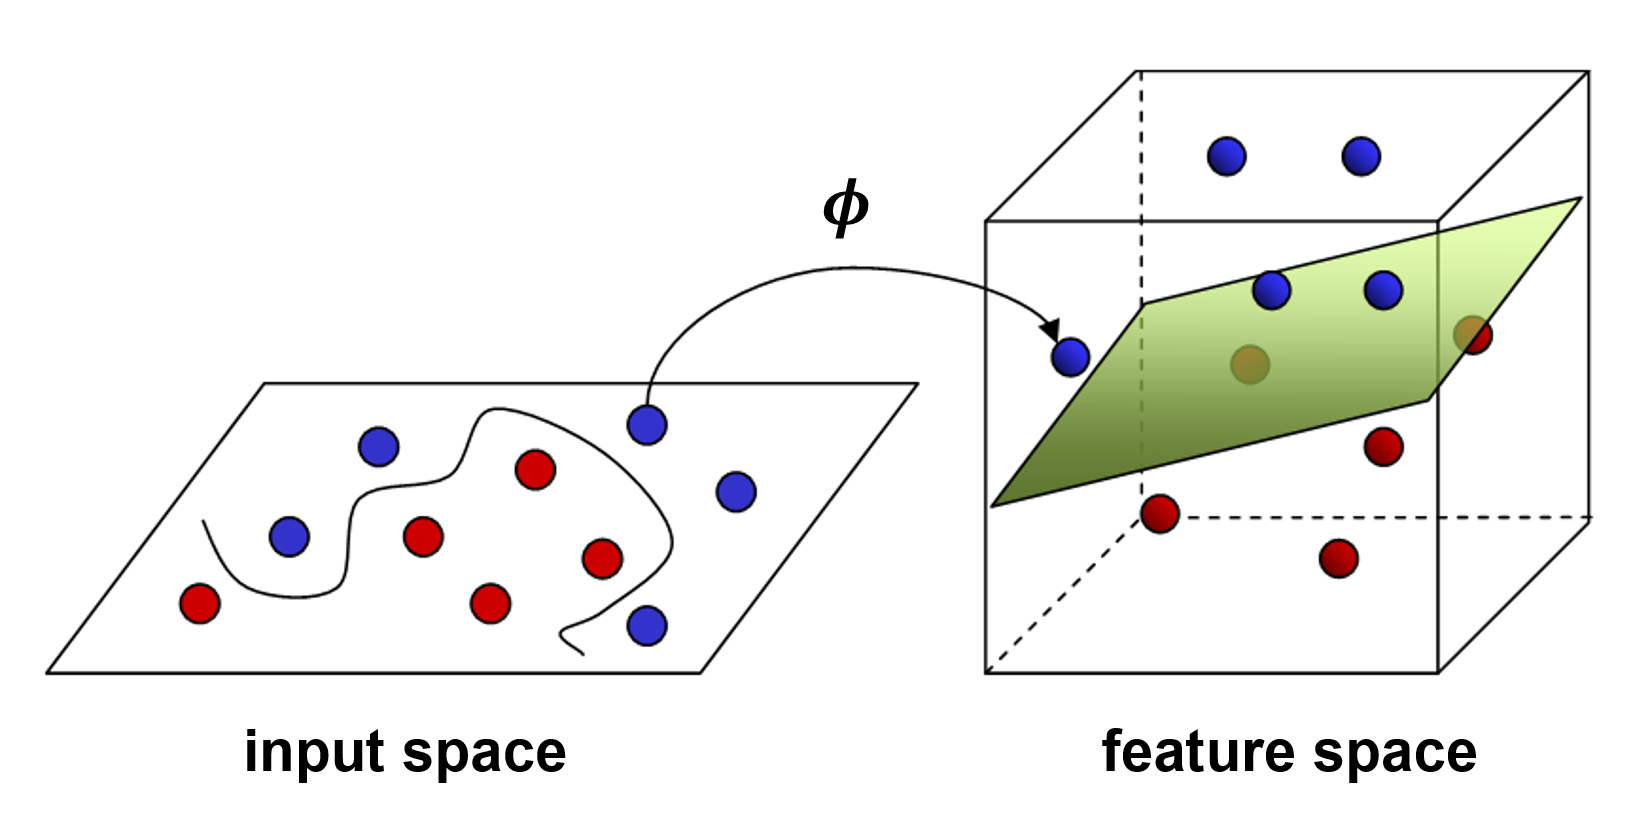
</font>



In [2]:
# Generate data that we are going to use in this exercise
# Please, do not change this cell
from sklearn.model_selection import train_test_split
from sklearn import datasets

circles = datasets.make_circles(n_samples=100, shuffle = True, noise = 0.05, random_state = 111)
circles_pd = pd.DataFrame({'x':circles[0][:,0], 'y':circles[0][:,1], 'class':circles[1]})
circles_pd['class'] = circles_pd['class'].astype('category')

circles_pd_train, circles_pd_test = train_test_split(circles_pd, test_size = 0.4, random_state = 111)

<font color='red'> Below we visualise the dataset to understand the scale of the problem we are facing.
</font>

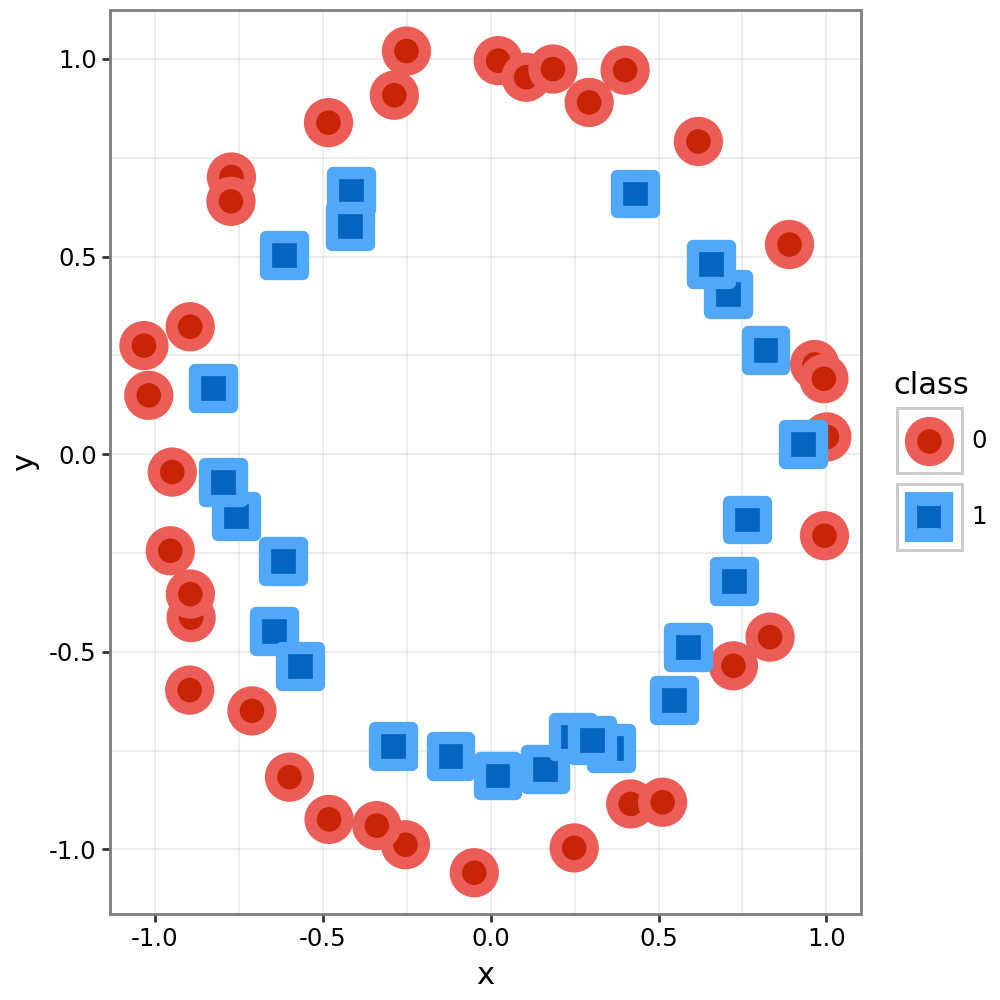

In [ ]:
fig = (
    ggplot(data = circles_pd_train,
          mapping = aes(x = 'x', y = 'y')) +
    geom_point(aes(shape = 'class',
                   fill = 'class',
                   colour = 'class'),
               size = 5.0,
               stroke = 2.5) +
    labs(
        title ='',
        x = 'x',
        y = 'y',
    ) +
    theme_bw() +
    scale_color_manual(['#EC5D57', '#51A7F9']) +
    scale_fill_manual(['#C82506', '#0365C0']) +
    scale_shape_manual(['o', 's']) +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black'))
).show()

<font color='red'> Does not look very promising indeed.
</font>

<font color='red'>**(Homework exercise 2- a)** Train both `DecisionTreeClassifier` with low `max_depth = 5` (to avoid strong overfitting) and `LogisticRegression` (use the same solver `lbfgs` for simplicity) from the previous exercise on these points. Measure and report the performance of the models on test points. (1 point)
</font>

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

##### YOUR CODE STARTS #####
DT_model = DecisionTreeClassifier(max_depth=5)
DT_model.fit(circles_pd_train[['x', 'y']], circles_pd_train['class'])
dt_score = DT_model.score(circles_pd_test[['x', 'y']], circles_pd_test['class'])

logisticRegr = LogisticRegression(solver='lbfgs')
logisticRegr.fit(circles_pd_train[['x', 'y']], circles_pd_train['class'])
lg_score = logisticRegr.score(circles_pd_test[['x', 'y']], circles_pd_test['class'])
##### YOUR CODE ENDS #####

print(f'Decision Tree score is {dt_score} and Logistic Regression score is {lg_score}')

Decision Tree score is 0.575 and Logistic Regression score is 0.275


<font color='red'>**(Homework exercise 2- b)** In order to remedy the situation create a new variable `z` using two other variables, by projecting all 2D points onto a surface of a paraboloid (3D parabola) with a centre in (0, 0). This way, compute z coordinates for each 2D point in both training and test sets. Train the same models as in **2-a** now taking into account a newly created `z` variable. Report the final scores. (2 points)
</font>

In [ ]:
##### YOUR CODE STARTS #####
circles_pd_train['z'] = circles_pd_train['x']**2 + circles_pd_train['y']**2
circles_pd_test['z'] = circles_pd_test['x']**2 + circles_pd_test['y']**2
##### YOUR CODE ENDS #####

<font color='red'>If you did everything correctly in the previous cells, on the figure that is generated by the next cell, you should see two separable classes, which should be also reflected in improved scores for both models.
</font>

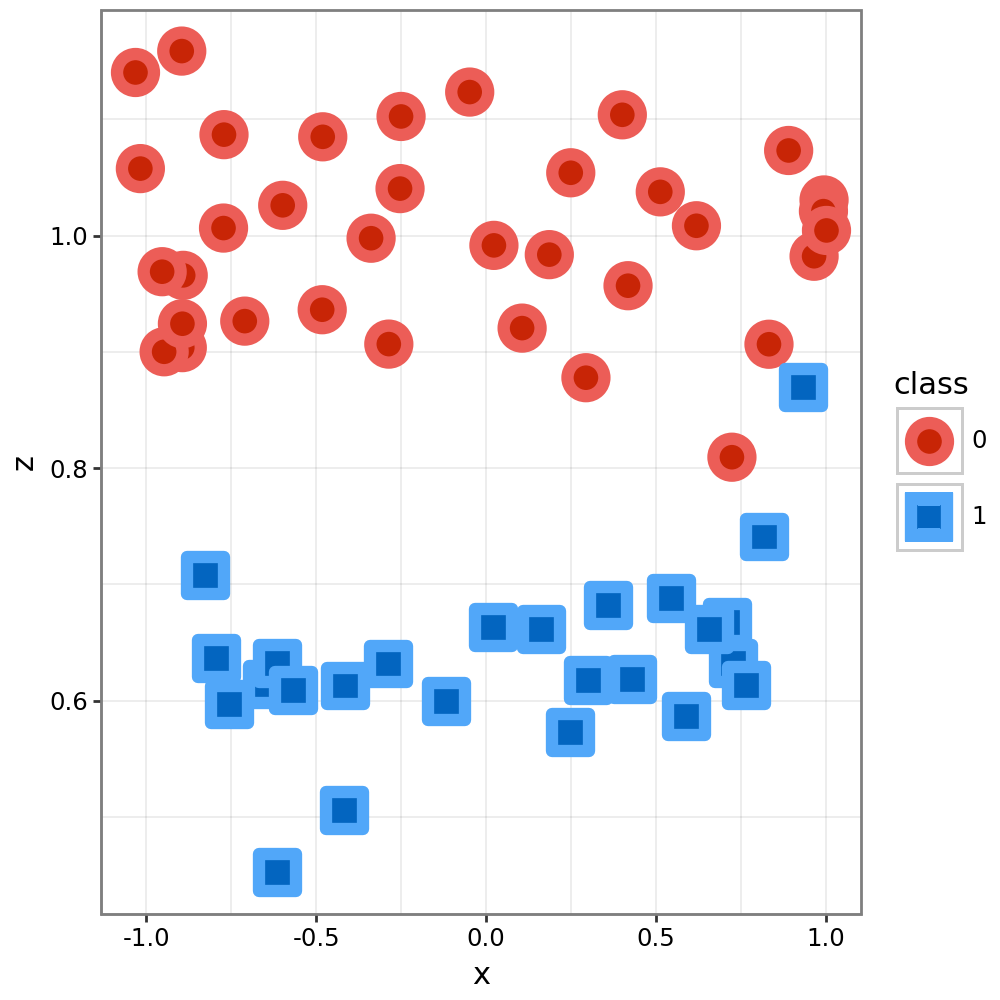

In [ ]:
fig = (
    ggplot(data = circles_pd_train,
          mapping = aes(x = 'x', y = 'z')) +
    geom_point(aes(shape = 'class',
                   fill = 'class',
                   colour = 'class'),
               size = 5.0,
               stroke = 2.5) +
    labs(
        title ='',
        x = 'x',
        y = 'z',
    ) +
    theme_bw() +
    scale_color_manual(['#EC5D57', '#51A7F9']) +
    scale_fill_manual(['#C82506', '#0365C0']) +
    scale_shape_manual(['o', 's']) +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black'))
).show()

In [ ]:
##### YOUR CODE STARTS #####
DT_model.fit(circles_pd_train[['x', 'y', 'z']], circles_pd_train['class'])
dt_score = DT_model.score(circles_pd_test[['x', 'y', 'z']], circles_pd_test['class'])

logisticRegr.fit(circles_pd_train[['x', 'y', 'z']], circles_pd_train['class'])
lg_score = logisticRegr.score(circles_pd_test[['x', 'y', 'z']], circles_pd_test['class'])
##### YOUR CODE ENDS #####

print(f'Improved Decision Tree score is {dt_score} and Logistic Regression score is {lg_score}')

Improved Decision Tree score is 0.975 and Logistic Regression score is 0.75


## Homework exercise 3 (3 points): Silhouette method
<font color='red'> In this exercise, we will get a feeling of how silhoutte method can be implemented in Python and then used to assess the number of hidden groups (clusters) in unlabled data.

<font color='red'> As we have discussed in the lecture, the silhouette score for every point from the dataset is given by the following formula:
$$ s(p) = \frac{b(p) - a(p)}{max(a(p),b(p)}$$
where $a(p)$ is an average distance from $p$ to other points that belong to the same cluster as $p$ ($a(p)$ is referred to as intra cluster distance)

<font color='red'> and $b(p)$ is a minimum average distance from $p$ to points of another cluster that $p$ does not belong to ($b(p)$ is referred to as nearest cluster distance).

<font color='red'> To get the final silhouette score $s$, $s(p)$ is averaged for all points in the dataset. The higher the silhouette score the better clustering. Let's implement it and evaluate several possible clusterings.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

<font color='red'> We start by creating a synthetic dataset with a few clusters.

In [ ]:
cluster_data = pd.DataFrame({'x':[2, 2, 2, 3, 3, 3, 5, 6, 7, 7], 'y':[9, 8, 5, 6, 5, 8, 5, 6, 4, 6]})
cluster_data = cluster_data.to_numpy()

<font color='red'> As you can see from the description, we will need to know distances between points in our dataset in order to calculate the silhouette score. Hence, the following function:

In [17]:
# Code from the second practice session
def compute_distances(points):
  # Compute L2 norm on difference between every point and the rest of the points
  distance_matrix = np.array([np.linalg.norm(point - points[:], axis=1) for point in points])

  # Force the values on the main diagonal to be inf
  distance_matrix[np.diag_indices(distance_matrix.shape[0])] = float('inf')

  return distance_matrix

<font color='red'>**(Homework exercise 3- a)** Implement silhouette method by completing the function `get_nearest_cluster_distance` and filling in the blanks in the function `manual_silhouette_score`. You will be able to test if your code works in the next task. (1.5 points)

In [11]:
def get_intra_cluster_distance(point_id, cluster_data, cluster_labels, distance_matrix):
  # Find the ids of the points belonging to the same cluster as the point with the given point_id
  intra_cluster_points_ids = np.flatnonzero(cluster_labels == cluster_labels[point_id])

  if len(intra_cluster_points_ids) > 1:
    # Take distances between the point with the given point_id and its cluster's neighbours
    intra_cluster_distances = [distance_matrix[point_id][neighbour_id] for neighbour_id in intra_cluster_points_ids if point_id != neighbour_id]

    return np.mean(intra_cluster_distances)

  else: # when we have one point in the cluster
    return 0

def get_nearest_cluster_distance(point_id, cluster_data, cluster_labels, distance_matrix):
  ##### YOUR CODE STARTS #####
  # find the ids of the points not belonging to the same cluster as the point with the given point_id
  near_cluster_points_ids = np.flatnonzero(cluster_labels != cluster_labels[point_id])

  #find the nearest cluster labels
  near_cluster_labels = np.unique(cluster_labels[near_cluster_points_ids])

  #take distances between the given point and the points belonging to the other clusters
  near_cluster_average_distances = []
  for label in near_cluster_labels:
    cluster_points_ids = np.flatnonzero(cluster_labels == label)
    near_cluster_distances = [distance_matrix[point_id][neighbour_id] for neighbour_id in cluster_points_ids]
    #compute the average distances
    near_cluster_average_distances.append(np.mean(near_cluster_distances))

  return min(near_cluster_average_distances) if near_cluster_average_distances else 0
  ##### YOUR CODE ENDS #####


def manual_silhouette_score(cluster_data, cluster_labels):
  silhouette_scores = np.zeros(len(cluster_data))

  #compute distances between all points
  distance_matrix = compute_distances(cluster_data)

  for point_id in range(len(cluster_data)):
    ##### YOUR CODE STARTS #####
    ic_dist = get_intra_cluster_distance(point_id, cluster_data, cluster_labels, distance_matrix)
    nc_dist = get_nearest_cluster_distance(point_id, cluster_data, cluster_labels, distance_matrix)
    if ic_dist != 0:
      silhouette_scores[point_id] = (nc_dist - ic_dist) / max(ic_dist, nc_dist)
    else:
      silhouette_scores[point_id] = 0
    ##### YOUR CODE ENDS #####
  return np.mean(silhouette_scores)

<font color='red'>**(Homework exercise 3- b)** Use `manual_silhouette_score` to compute silhouette score for as many clusterings as possible for the given dataset. Compare your scores to the ones computed by the scikit-learn function `silhouette_score` to make sure that your implementation works correctly. (1 point)

In [ ]:
##### YOUR CODE STARTS #####
# It is definately not meaningful to use 10 as and upper bound for the number of clusters, but it is the actual maximum number of possible ones (theoretically)
K_options = range(2, 10)
custom_silhouette_scores = []

for num_clusters in K_options:
  print(f"Number of clusters: {num_clusters}")
  clustering = KMeans(n_clusters=num_clusters, random_state=111).fit(cluster_data)

  # Calculate silhouette score using manual implementation
  custom_silhouette_score = manual_silhouette_score(cluster_data, clustering.labels_)
  custom_silhouette_scores.append(custom_silhouette_score)
  print(f"Custom silhouette score: {custom_silhouette_score}")

  # Calculate silhouette score using scikit-learn implementation
  sklearn_silhouette_score = silhouette_score(cluster_data, clustering.labels_)
  print(f"scikit-learn silhouette score: {sklearn_silhouette_score}")

  # Compare the two scores
  assert np.allclose(custom_silhouette_score, sklearn_silhouette_score)
##### YOUR CODE ENDS #####

Number of clusters: 2
Custom silhouette score: 0.4179970491289261
scikit-learn silhouette score: 0.4179970491289261
Number of clusters: 3
Custom silhouette score: 0.559986721021637
scikit-learn silhouette score: 0.559986721021637
Number of clusters: 4
Custom silhouette score: 0.4053085484794073
scikit-learn silhouette score: 0.4053085484794073
Number of clusters: 5
Custom silhouette score: 0.42289252013463746
scikit-learn silhouette score: 0.42289252013463746
Number of clusters: 6
Custom silhouette score: 0.29010821513284213
scikit-learn silhouette score: 0.29010821513284213
Number of clusters: 7
Custom silhouette score: 0.2360405551961823
scikit-learn silhouette score: 0.2360405551961823
Number of clusters: 8
Custom silhouette score: 0.05857864376269051
scikit-learn silhouette score: 0.05857864376269051
Number of clusters: 9
Custom silhouette score: 0.029289321881345254
scikit-learn silhouette score: 0.029289321881345254


<font color='red'>**(Homework exercise 3- c)** Finally, use matplotlib to visualise the resulting silhouette scores. Explore this visualisation and report the most reasonable number of clusters. (0.5 points)

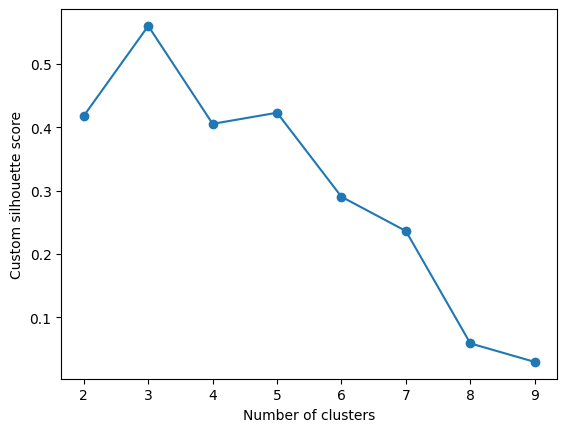

In [ ]:
##### YOUR CODE STARTS #####
plt.plot(K_options, custom_silhouette_scores, marker='o')
##### YOUR CODE ENDS #####
plt.ylabel('Custom silhouette score')
plt.xlabel('Number of clusters')
plt.xticks(K_options)
plt.show()

According to the above plot the most reasonable number of clusters is **3**

<font color='red'> Verify your guess by plotting `cluster_data` (you can use your favourite library for visualisation).

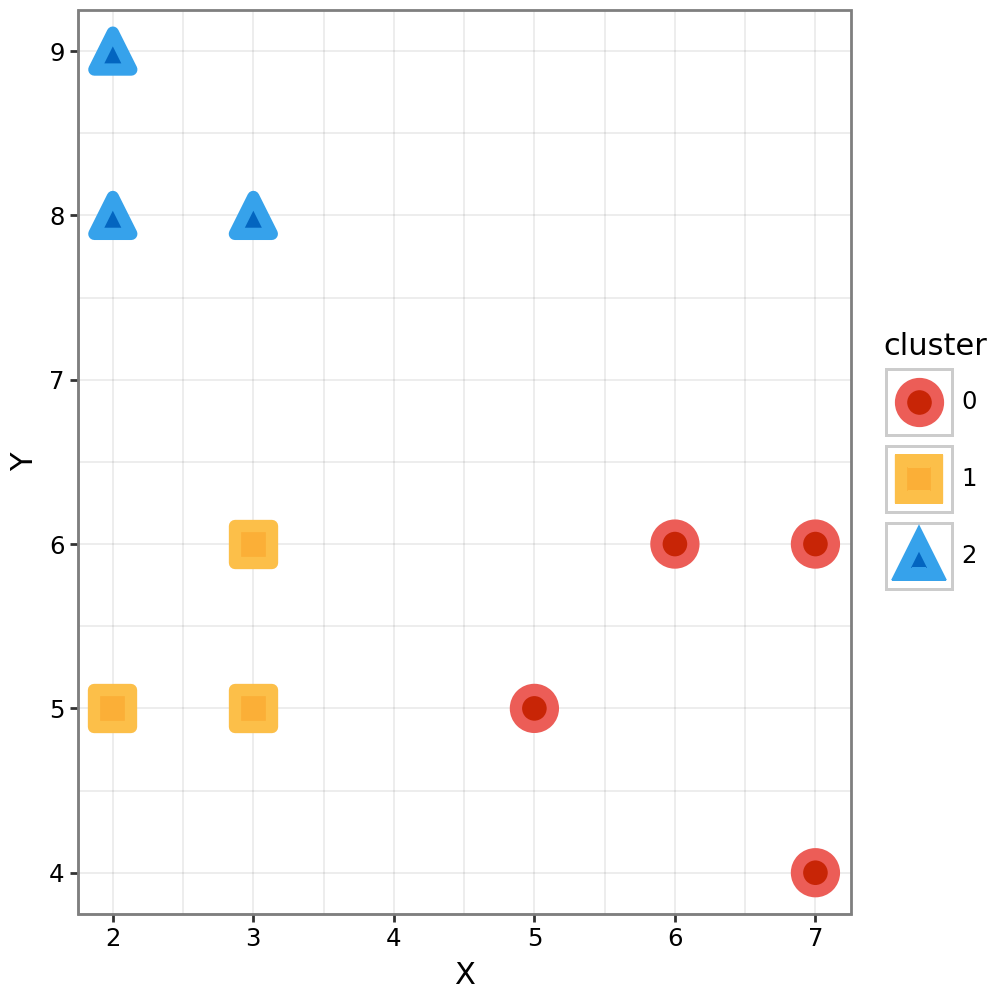

In [ ]:
##### YOUR CODE STARTS #####
cluster_labels = KMeans(n_clusters=3).fit_predict(cluster_data)

cluster_df = pd.DataFrame(cluster_data, columns=['x', 'y'])
cluster_df['cluster'] = cluster_labels.astype(str)

fig = (
    ggplot(data=cluster_df, mapping=aes(x='x', y='y')) +
    geom_point(aes(shape='cluster', fill='cluster', colour='cluster'),
               size=5.0, stroke=2.5) +
    labs(title='', x='X', y='Y') +
    theme_bw() +
    scale_color_manual(['#EC5D57', '#FCBF49', '#36A2EB']) +
    scale_fill_manual(['#C82506', '#FBAF37', '#0365C0']) +
    scale_shape_manual(['o', 's', '^']) +
    theme(figure_size=(5, 5),
          axis_line=element_line(size=0.5, colour='black'),
          panel_grid_major=element_line(size=0.05, colour='black'),
          panel_grid_minor=element_line(size=0.05, colour='black'),
          axis_text=element_text(colour='black'))
)
fig.show()
##### YOUR CODE ENDS #####

# Bonus exercises
*(NB, these are optional exercises!)*

## Bonus exercise 1 (0.5 bonus points):

<font color='red'> Apply t-SNE or UMAP on MNIST data, plot the results as we have done for PCA. Visually compare the results. Which one in your opinion worked better? What are the advantages and disadvantages of these methods? </font>

In [4]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.7 MB/s eta 0:00:00


In [6]:
from sklearn.manifold import TSNE
import umap

# t-SNE transformation
tsne = TSNE(n_components=2)
mnist_tsne = tsne.fit_transform(train_images)
tsne_df = pd.DataFrame(mnist_tsne, columns=['x', 'y'])
tsne_df['label'] = train_labels.astype(str)

# UMAP transformation
umap_model = umap.UMAP(n_components=2)
mnist_umap = umap_model.fit_transform(train_images)
umap_df = pd.DataFrame(mnist_umap, columns=['x', 'y'])
umap_df['label'] = train_labels.astype(str)

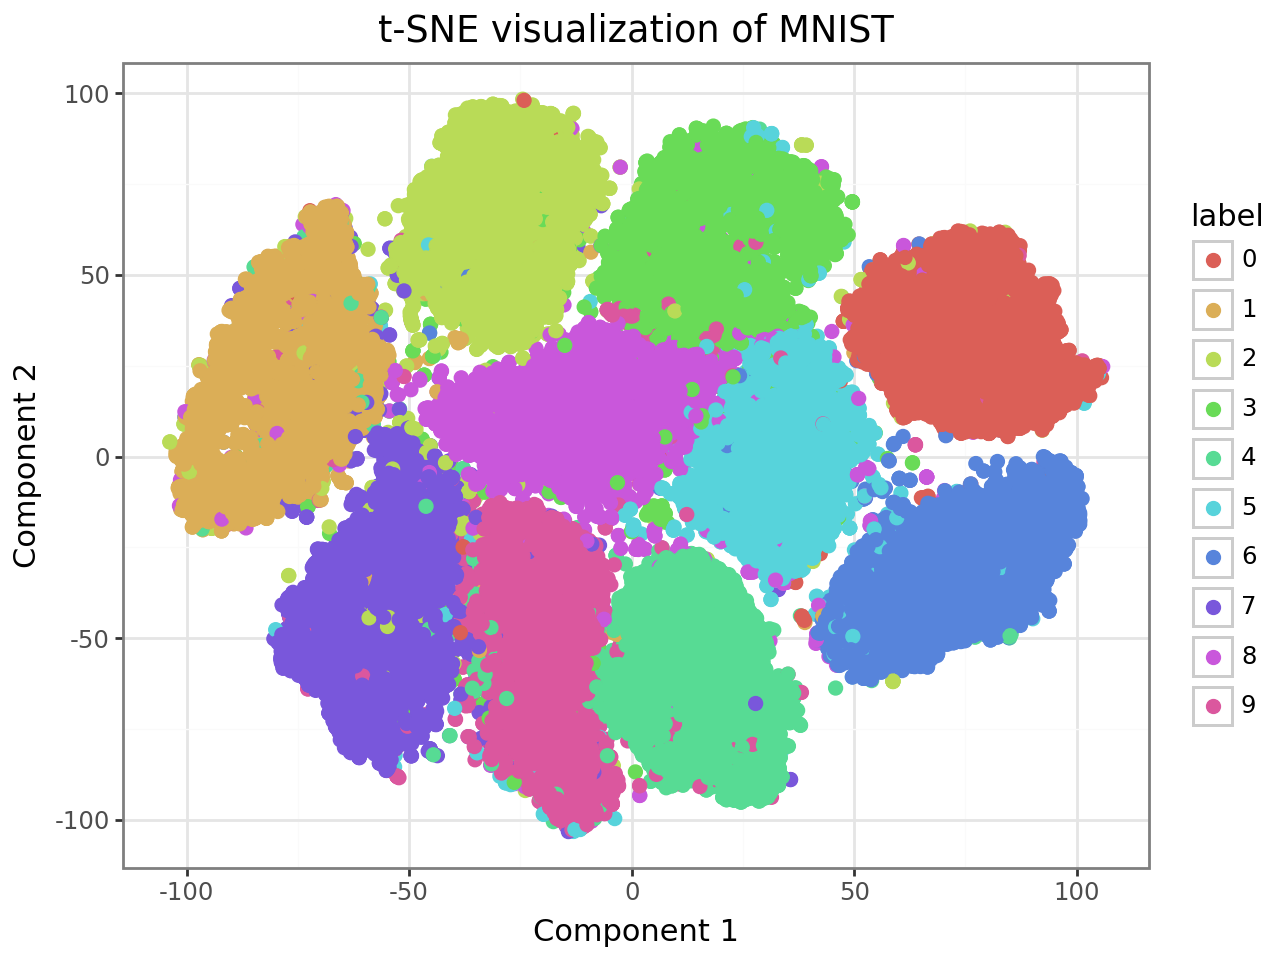

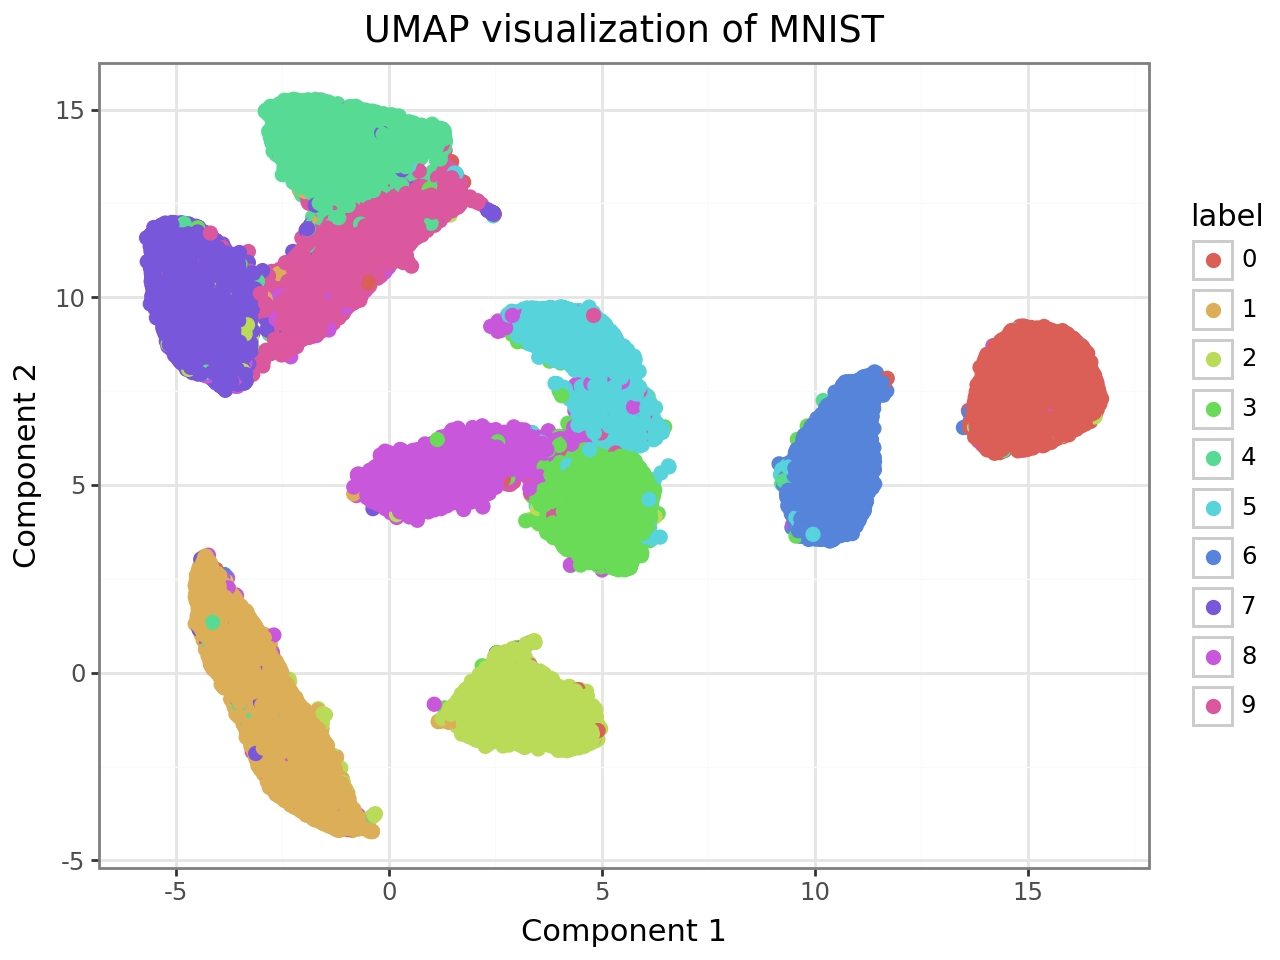

In [7]:
fig_tsne = (
    ggplot(data=tsne_df, mapping=aes(x='x', y='y')) +
    geom_point(aes(fill='label', colour='label'), size=2.5, stroke=0.3) +
    labs(title='t-SNE visualization of MNIST', x='Component 1', y='Component 2') +
    theme_bw()
)
fig_tsne.show()

fig_umap = (
    ggplot(data=umap_df, mapping=aes(x='x', y='y')) +
    geom_point(aes(fill='label', colour='label'), size=2.5, stroke=0.3) +
    labs(title='UMAP visualization of MNIST', x='Component 1', y='Component 2') +
    theme_bw()
)
fig_umap.show()

UMAP provides a more compact and well-separated representation of clusters compared to t-SNE, while also preserving both local and global structures more effectively. It is computationally more efficient and scales well for large datasets. However, t-SNE can sometimes offer better separation between individual clusters and may be more suitable for certain classification and clustering tasks.

In practice, UMAP’s strong structure preservation can sometimes cause it to over-cluster or merge similar classes.

## Bonus exercise 2 (0.5 bonus points):

<font color='red'> Use the output of bonus exercise 1 (either from t-SNE or UMAP) to train your favourite ML model and compare its performance with the same model trained on the original data and on data transformed with conventional PCA. What differences you observe and why? </font>

In [11]:
tsne = TSNE(n_components=2)
mnist_tsne_train = mnist_tsne
mnist_tsne_test = tsne.fit_transform(test_images)

umap_model = umap.UMAP(n_components=2)
mnist_umap_train = mnist_umap
mnist_umap_test = umap_model.fit_transform(test_images)

pca = PCA(n_components=2)
mnist_pca_train = pca.fit_transform(train_images)
mnist_pca_test = pca.transform(test_images)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {'Original': (train_images, test_images),
          'PCA': (mnist_pca_train, mnist_pca_test),
          't-SNE': (mnist_tsne_train, mnist_tsne_test),
          'UMAP': (mnist_umap_train, mnist_umap_test)}

results = {}
for name, (X_train, X_test) in models.items():
    clf = RandomForestClassifier(n_estimators=100, random_state=111)
    clf.fit(X_train, train_labels)
    predictions = clf.predict(X_test)
    accuracy = accuracy_score(test_labels, predictions)
    results[name] = accuracy
    print(f"Accuracy using {name} transformed data: {accuracy:.4f}")

Accuracy using Original transformed data: 0.9701
Accuracy using PCA transformed data: 0.4231
Accuracy using t-SNE transformed data: 0.7514
Accuracy using UMAP transformed data: 0.1637


The original MNIST data achieves the highest accuracy, as it retains the most information. PCA performs poorly since reducing to two dimensions results in significant data loss. t-SNE achieves a moderate, capturing local structures but not necessarily forming an ideal feature space for classification.

UMAP performs the worst because it prioritizes preserving global manifold structure over class separation, making it less suitable for supervised learning. This shows the point from the previous part, that dimensionality reduction methods are useful for visualization but often reduce classification performance compared to using the full dataset and can contribute poorly to the overall classification capability comparing to the human's interpretability.

## Bonus exercise 3 (4 bonus points):

<font color='red'> In this Exercise, you are going to implement K-means step by step and run it on the three datasets we used before (moons, circles and the one without a structure)   

* Implement K-means using only numpy and basic python operations (**no sklearn**)
* Run it on the same three datasets used before (moons, circles and the one without a structure). Compare the resulting clusters with those we got before using sklearn KMeans.
* For every dataset, plot the sum of euclidean distances between points in a cluster and its center, at every step.
* For one dataset of the three, make a gif or any animation to show how the means evolve during training. (hint: you can use this [library](https://pypi.org/project/gif/) or any other ploting method of your choice. Use a smaller number of samples to get better visuals.)</font>

In [3]:
!pip install gif

In [14]:
import gif
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import KMeans

moons_data, _ = make_moons(n_samples=100, noise=0.05)
circles_data, _ = make_circles(n_samples=100, noise=0.05)
cluster_data = pd.DataFrame({'x':[2, 2, 2, 3, 3, 3, 5, 6, 7, 7], 'y':[9, 8, 5, 6, 5, 8, 5, 6, 4, 6]}).to_numpy()

In [73]:
def compute_pairwise_distances(X, centroids):
    distances = np.zeros((X.shape[0], centroids.shape[0]))
    for i, x in enumerate(X):
        for j, c in enumerate(centroids):
            distances[i, j] = np.sqrt(np.sum((x - c) ** 2))
    return distances

def initialize_centroids(X, k):
    return X[np.random.choice(X.shape[0], k, replace=False)]

@gif.frame
def plot_iteration(X, centroids, labels):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='black')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=50, label='Centroids')
    plt.legend()

def kmeans(X, k, dataset_name=None, max_iters=100):
    centroids = initialize_centroids(X, k)
    frames = []
    for _ in range(max_iters):
        distances = compute_pairwise_distances(X, centroids)
        labels = np.argmin(distances, axis=1)
        frames.append(plot_iteration(X, centroids, labels))
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    gif.save(frames, f"{dataset_name}_kmeans_evolution.gif", duration=100)
    return centroids, labels

def plot_clusters(X, centroids, labels, title):
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='black')
    if centroids is not None:
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=50, label='Centroids')
    plt.title(title)
    plt.show()

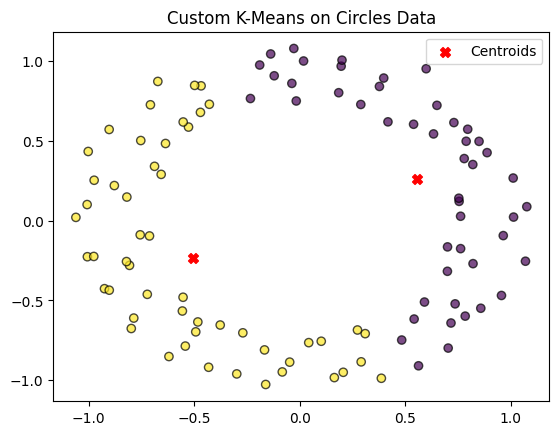

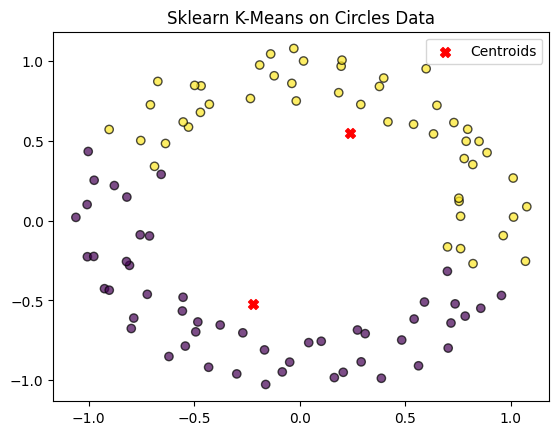

Silhouette Score for Circles dataset: 0.3934


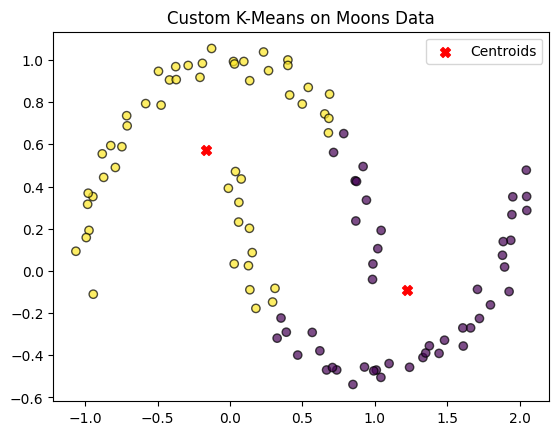

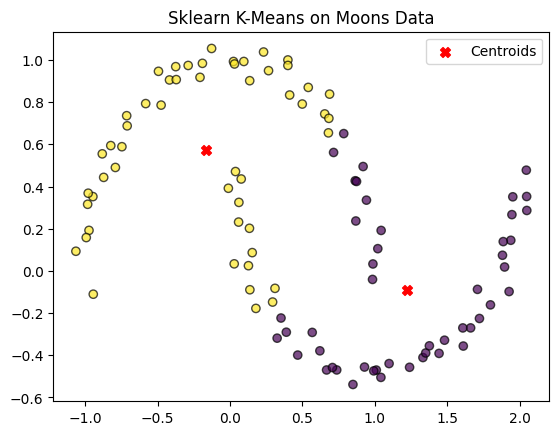

Silhouette Score for Moons dataset: 0.4787


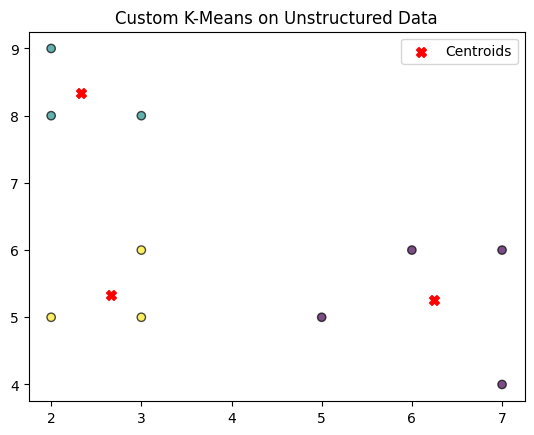

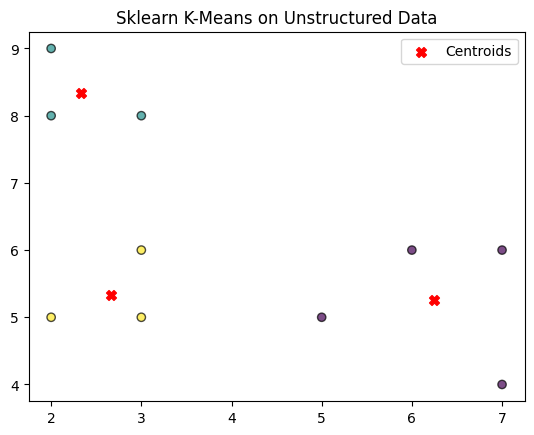

Silhouette Score for Unstructured dataset: 0.5600


In [54]:
for data, name, k in [(circles_data, 'Circles', 2), (moons_data, 'Moons', 2), (cluster_data, 'Unstructured', 3)]:
    centroids, labels = kmeans(data, k, name)
    plot_clusters(data, centroids, labels, f'Custom K-Means on {name} Data')
    kmeans_sklearn = KMeans(n_clusters=k, random_state=111).fit(data)
    plot_clusters(data, kmeans_sklearn.cluster_centers_, kmeans_sklearn.labels_, f'Sklearn K-Means on {name} Data')
    silhouette = manual_silhouette_score(data, labels)
    print(f'Silhouette Score for {name} dataset: {silhouette:.4f}')

    # Create GIF for each dataset
    gif_filename = f'kmeans_{name.lower()}_evolution.gif'
    gif.save([plot_iteration(data, centroids, labels) for _ in range(10)], gif_filename, duration=100)

K-means is not the best algorithm for moons and circles data because it assumes convex clusters and struggles with non-linear structures. Better alternatives could be Spectral clustering, that works well for non-convex clusters by leveraging graph-based similarity, and DBSCAN, as it identifies arbitrary-shaped clusters based on density.

Moons data will be well clustered in its original form by both algorithms, but circles data required a modification of the factor parameter because the default factor make the inner and outer circles too close, causing overlap and making separation difficult even for Spectral clustering and DBSCAN.

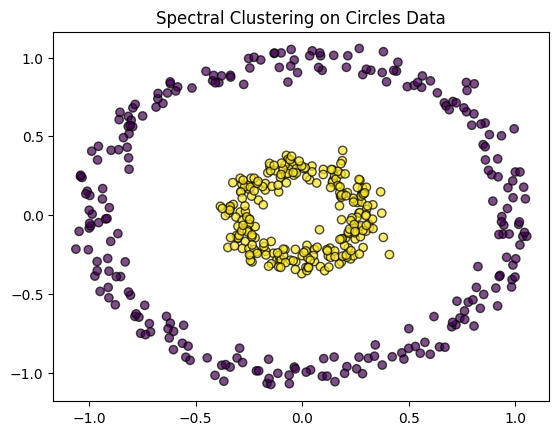

Silhouette Score (Spectral) for Circles dataset: 0.2084


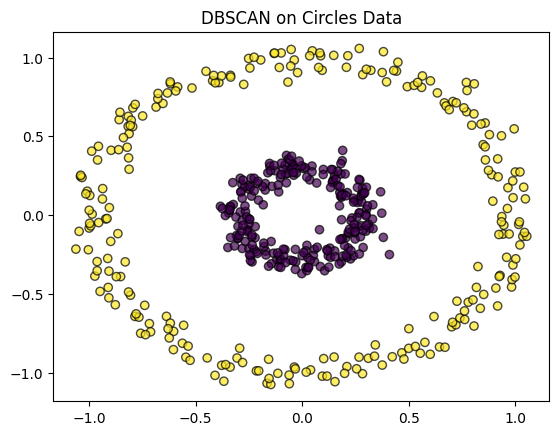

Silhouette Score (DBSCAN) for Circles dataset: 0.2084


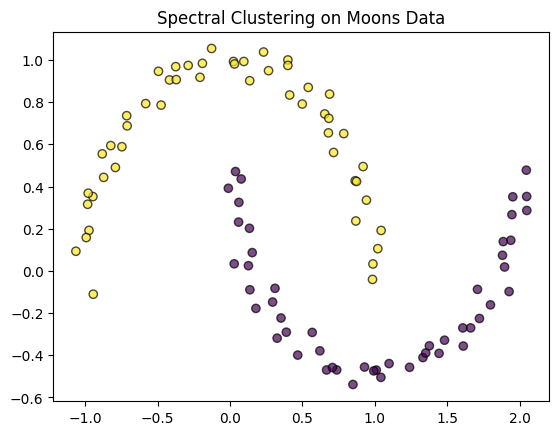

Silhouette Score (Spectral) for Moons dataset: 0.3211


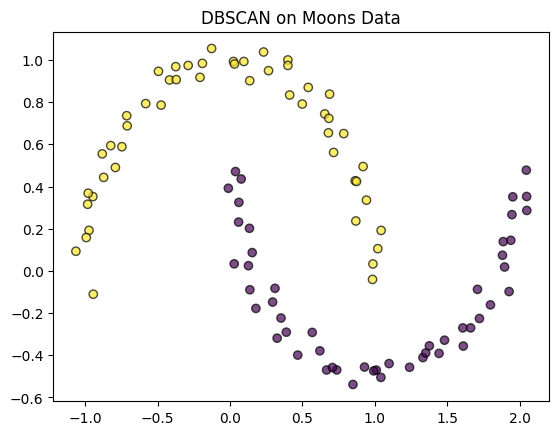

Silhouette Score (DBSCAN) for Moons dataset: 0.3211


In [74]:
from sklearn.cluster import SpectralClustering, DBSCAN

circles_data, _ = make_circles(n_samples=500, noise=0.05, factor=0.3)

for data, name, k in [(circles_data, 'Circles', 2), (moons_data, 'Moons', 2)]:
    spectral = SpectralClustering(n_clusters=k, affinity='rbf', gamma=500, random_state=111).fit(data)
    plot_clusters(data, None, spectral.labels_, f'Spectral Clustering on {name} Data')
    silhouette_spectral = manual_silhouette_score(data, spectral.labels_)
    print(f'Silhouette Score (Spectral) for {name} dataset: {silhouette_spectral:.4f}')

    dbscan = DBSCAN(eps=0.3, min_samples=4).fit(data)
    plot_clusters(data, None, dbscan.labels_, f'DBSCAN on {name} Data')
    if len(set(dbscan.labels_)) > 1:
        silhouette_dbscan = manual_silhouette_score(data, dbscan.labels_)
        print(f'Silhouette Score (DBSCAN) for {name} dataset: {silhouette_dbscan:.4f}')

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you spend on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

This homework took me approximately a few hours to complete even with extra tasks, so I found it relatively simple compared to the depth of the topic.
The lab could be expanded to include more diverse clustering algorithms on the real-world datasets (at least Gaussian mixture models, as an example of a probabilistic approach). Personally I would love to train an autoencoder on unlabeled data or even try unsupervised text clustering with BERT embeddings, something like that, more practical tasks.

Given the strong mathematical and practical background of our lecturer and assistants, I would suggest incorporating more of their own expertise and experience in advanced problem-solving.

Overall, providing both theoretical depth and practical real-world applications would greatly enhance the learning experience!!!

# <font color='red'>  End of the homework. Please don't delete this cell.</font>